# <span style="color:#c8a2c8; font-weight:bold">Visuals Exploratory Notebook</span>

## <span style="color:#c8a2c8">Post project workbook</span>

In [1]:
# import libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [2]:
# dataset loading

DATASET_CSV_PATH = "data/cleaned/properties_final_irene.csv"
MANIP_DATASET_CSV_PATH = "data/cleaned/properties_final_irene_after_analysis.csv"
df = pd.read_csv(DATASET_CSV_PATH)
def_df = df.copy()

In [3]:
# Numerizing 'epc_score' column

print(df['epc_score'].unique())

epc_scores = ["A++", "A+", "A", "B", "C", "D", "E", "F", "G"]
epc_mapping = {
    "A++" : 1,
    "A+" : 2, 
    "A" : 3, 
    "B+": 4,
    "B" : 5,
    "C" : 6,
    "D" : 7,
    "E+": 8,
    "E" : 9, 
    "F" : 10,
    "G" : 11
}

def_df['epc_score'] = def_df['epc_score'].replace(epc_mapping)

# Saving changes in data/cleaned
def_df.to_csv(MANIP_DATASET_CSV_PATH, index=False)

print("Values in 'epc_score' have been successfully replaced with int values in def_df dataset.")

<StringArray>
['A+', 'B', 'G', nan, 'D', 'C', 'A', 'E', 'F', 'A++', 'B+', 'E+']
Length: 12, dtype: str
Values in 'epc_score' have been successfully replaced with int values in def_df dataset.


### <span style="color:#c8a2c8; font-weight:bold">1. Correlation Matrix</span>
### <span style="color:#c8a2c8">Focus: Price Driver</span>

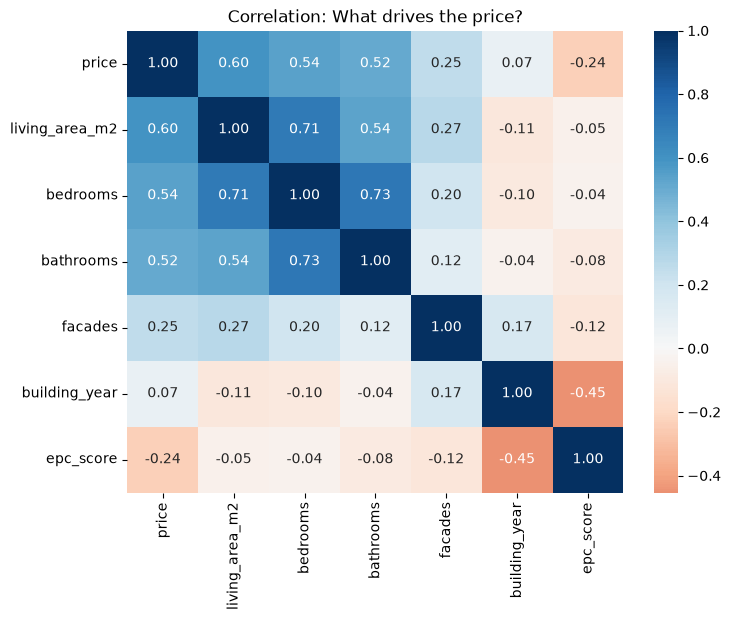

In [4]:
# selectioning numeric values relevant for price
columns = ['price', 'living_area_m2', 'bedrooms', 'bathrooms', 'facades', 'building_year', 'epc_score']
corr = def_df[columns].corr()

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(
    corr, 
    annot=True,
    cmap='RdBu',
    center=0,
    fmt='.2f'
)
plt.title("Correlation: What drives the price?")
plt.savefig(
    f"corr_mat_price.png", 
    bbox_inches='tight', 
    dpi=330
)
plt.show()

### <span style="color:#c8a2c8; font-weight:bold">2. Scatterplot</span>
### <span style="color:#c8a2c8">Price vs Surface</span>

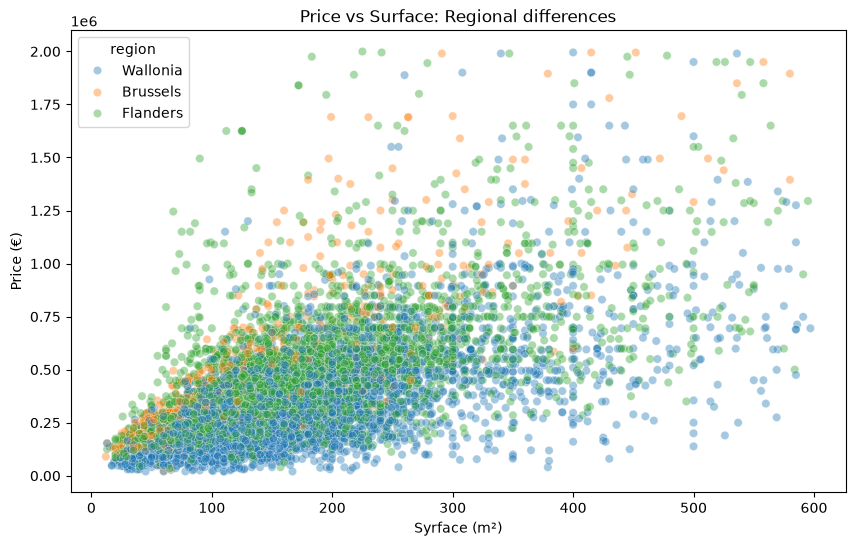

In [5]:
plt.figure(figsize=(10,6))

# applying filters on extreme data (outliers)
df_filtered = def_df[(def_df['living_area_m2'] < 600) & (def_df['price'] < 2000000)]

# Plot 1: price_vs_surf_regions.png
sns.scatterplot(
    data=df_filtered,
    x='living_area_m2',
    y='price',
    hue='region',
    alpha=0.4
)
plt.title("Price vs Surface: Regional differences")
plt.xlabel("Syrface (m²)")
plt.ylabel("Price (€)")
plt.savefig(
    f"price_vs_surf_regions.png", 
    bbox_inches='tight', 
    dpi=330
)
plt.show()

<Figure size 1000x600 with 0 Axes>

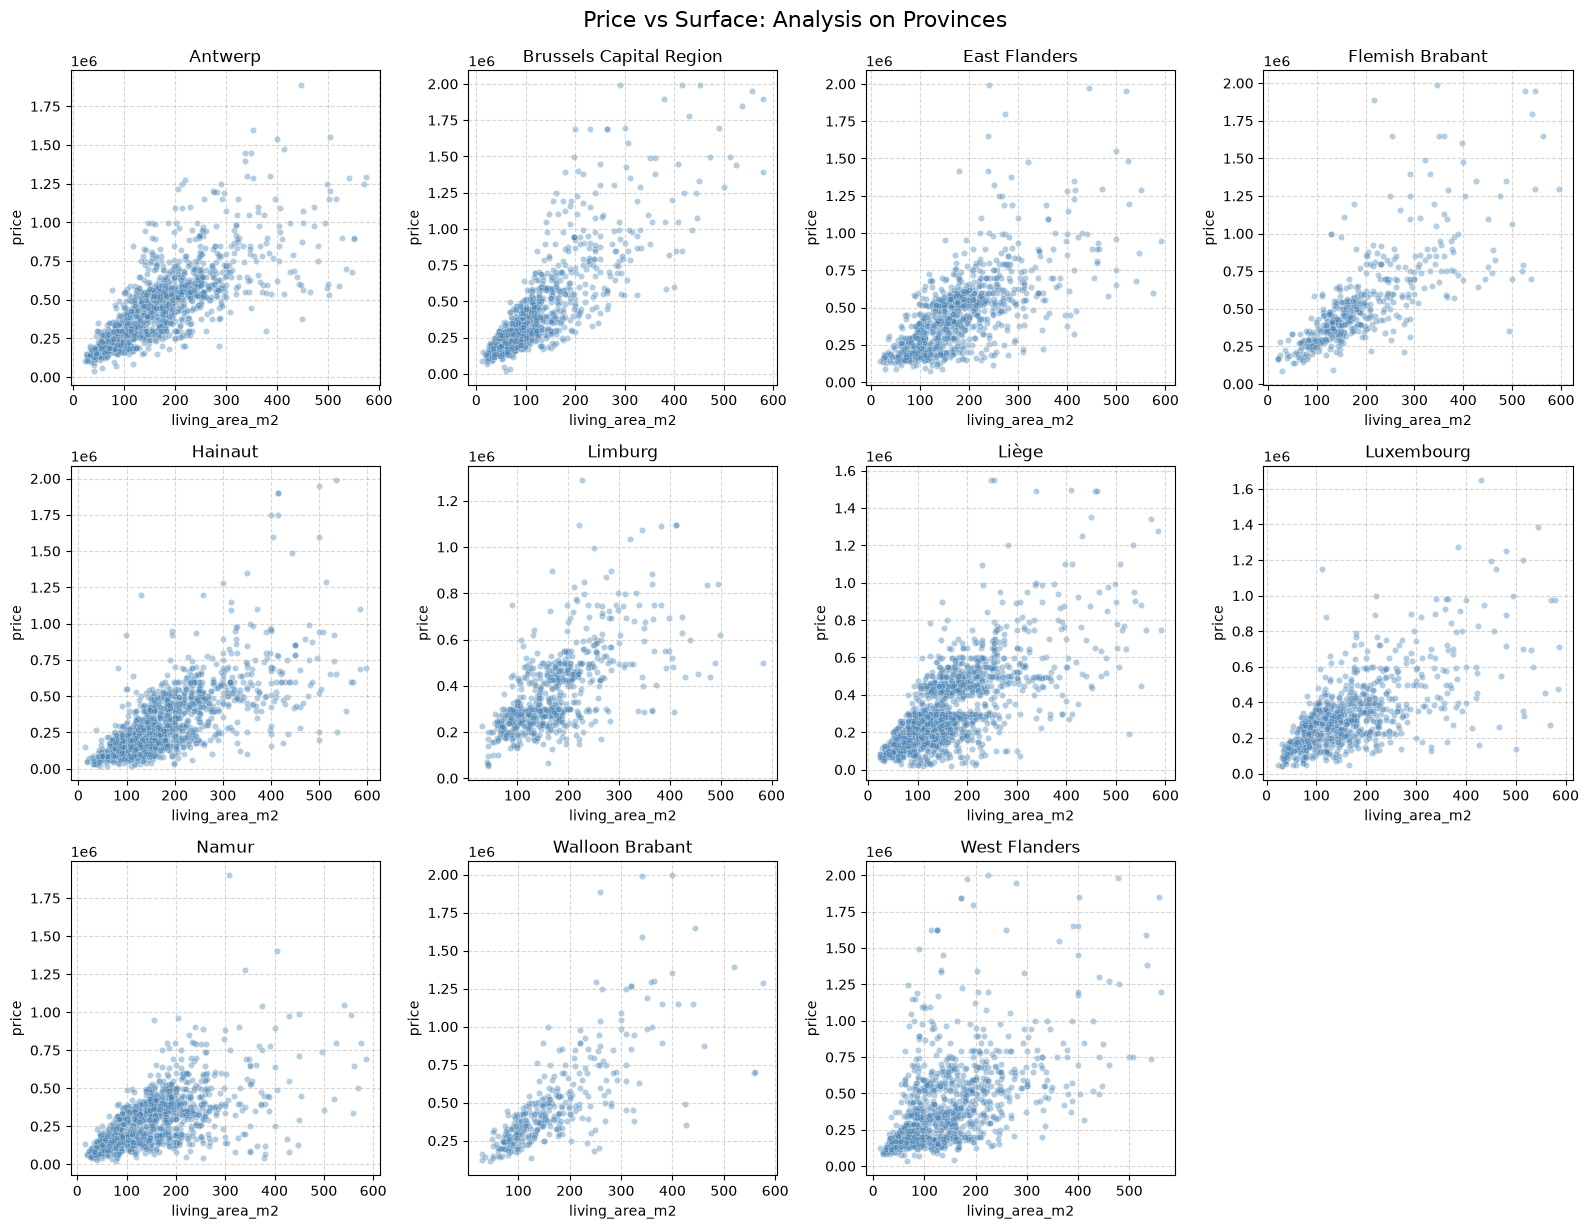

In [8]:
plt.figure(figsize=(10,6))

# Plot 2: price_vs_surf_provinces.png

# explicitly convert to numeric, forcing errors to NaN
def_df['price'] = pd.to_numeric(def_df['price'], errors='coerce')
def_df['living_area_m2'] = pd.to_numeric(def_df['living_area_m2'], errors='coerce')
# removing NaN and filtering
mask = np.isfinite(def_df['price']) & np.isfinite(def_df['living_area_m2'])
df_clean = def_df[mask].dropna(subset=['province']).copy()
df_filtered = df_clean[
    (df_clean['living_area_m2'] > 0) & 
    (df_clean['living_area_m2'] < 600) & 
    (df_clean['price'] < 2000000)
]
# manual set-up of the grid
provinces = sorted(df_filtered['province'].unique())
n_plots = len(provinces)
cols = 4
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

# creating fig and axes
for i, province in enumerate(provinces):
    ax = axes[i]
    subset = df_filtered[df_filtered['province'] == province]

    sns.scatterplot(
        data=subset,
        x='living_area_m2',
        y='price',
        ax=ax,
        alpha=0.4,
        color='steelblue',
        s=20
    )
    ax.set_title(province) # name of province as panel title
    ax.grid(True, linestyle='--', alpha=0.5)

# cleaning of empty axes
for i in range(n_plots, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle("Price vs Surface: Analysis on Provinces", fontsize=16, y=1.02)
plt.savefig(
    f"price_vs_surf_provinces.png", 
    bbox_inches='tight', 
    dpi=330
)
plt.show()